## Avaliando arquivo FIS_NF.CSV

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_DIR = Path().cwd().parent / "data"

PosixPath('/Users/marcosilva/Projetos/FAMaringa/data')

In [4]:
# Importando dados
df_raw = pd.read_csv(DATA_DIR / "FIS_NF.csv", sep=";")

# Verificando dimensões do dataset
print("Número de linhas:", df_raw.shape[0])
print("Número de colunas:", df_raw.shape[1])

Número de linhas: 35415
Número de colunas: 43


In [5]:
# Verificando os tipos de dados das colunas
print(df_raw.dtypes)

CD_EMPRESA            int64
NR_FATURA             int64
DT_FATURA               str
U_VERSION               str
CD_PESSOA             int64
CD_EMPFAT             int64
CD_GRUPOEMPRESA       int64
CD_OPERADOR           int64
DT_CADASTRO             str
NR_NF                 int64
CD_SERIE            float64
DT_EMISSAO              str
TP_ORIGEMEMISSAO      int64
TP_MODDCTOFISCAL      int64
TP_OPERACAO             str
TP_SITUACAO             str
CD_EMPRESAORI       float64
NR_TRANSACAOORI     float64
DT_TRANSACAOORI         str
CD_OPERACAO           int64
CD_CONDPGTO           int64
CD_MODELONF         float64
NR_PRE              float64
HR_SAIDA                str
DT_SAIDAENTRADA         str
CD_COMPVEND           int64
IN_FRETE            float64
CD_USUIMPRESSAO     float64
DT_IMPRESSAO            str
NR_IMPRESSAO        float64
PR_DESCONTO         float64
QT_FATURADO           int64
VL_TOTALPRODUTO     float64
VL_DESPACESSOR      float64
VL_FRETE            float64
VL_SEGURO           

In [6]:
# Conferindo valores nulos
((df_raw.isnull().sum() / df_raw.shape[0]) *100).round(4).sort_values(ascending=False).head(15)

IN_FRETE           100.0000
CD_USUIMPRESSAO     98.3114
DT_IMPRESSAO        98.3114
NR_IMPRESSAO        98.3114
CD_MODELONF         50.9728
NR_PRE              15.2252
VL_SEGURO           11.7182
VL_FRETE            11.7182
VL_DESPACESSOR      11.7182
CD_SERIE             0.0395
DT_TRANSACAOORI      0.0028
NR_TRANSACAOORI      0.0028
CD_EMPRESAORI        0.0028
PR_DESCONTO          0.0000
VL_TOTALPRODUTO      0.0000
dtype: float64

In [7]:
# Conferindo estatisticas descritivas
df_raw.describe().T

In [8]:
# Conferindo amostra
df_raw.sample(10).T

A análise descritiva apresenta bons insights para as colunas do tipo VL (Valor).

- ```VL_TOTALPRODUTO``` e ```VL_TOTALNOTA```: Apresentam um desvio padrão relativamente alto, com valor máximo igual a R$603.747,69
  
- ```VL_DESPACESSOR``` e ```VL_DESCONTO```: É preciso avaliar melhor os dados pois a maioria apresenta valor igual a Zero.

- ```VL_FRETE``` : Frete não cobrado em pelo menos metade dos registros.

- ```VL_SEGURO```, ```VL_BASEICMSSUBS```, ```VL_ICMSSUBST``` e```VL_IPI``` : Todos os registros estão com valor igual Zero.

- ```VL_BASEICMS``` e ```VL_ICMS```: Apresentam registros válidos e compatíveis com os valores das notas.


In [9]:
# Conferindo os valores únicos da coluna VL_DESPACESSOR
df_raw['VL_DESPACESSOR'].value_counts()

VL_DESPACESSOR
0.00     31259
99.00        2
44.90        2
46.95        1
10.90        1
Name: count, dtype: int64

In [10]:
# Conferindo os registros com VL_DESPACESSOR  para identificar possíveis padronizações ou inconsistências nos dados
df_raw[df_raw['VL_DESPACESSOR'] != 0.0].dropna(subset=['VL_DESPACESSOR']).T

A coluna ```VL_DESPACESSOR``` contém 11,7% de valores ausentes, o nome não é claro sobre a origem porem o padrão ```VL``` indica ser algum Valor/Custo. Há apenas 6 registros não zerados ou não nulos em todo o dataset.

Avaliando os unícos registros desse dado em todo o conjunto, nota-se que ele faz parte da Base de Cálculo do ICMS, dessa forma, não pode ser ignorado muito menos excluído.

Sendo assim, como a coluna referente ao Frete contem a mesma quantidade de registros ausentes, vamos completar os dados ausentes com Zero. 

Para fins de cálculo, essa coluna vai ser tratada como despesa considerando a sua participação no ICMS.

As colunas ```CD_MODELONF```,```CD_USUIMPRESSAO``` e ```NR_IMPRESSAO```, referentes a Códigos e Números de registro, apresentam a grande maioria dos dados ausentes. Vamos avaliar a necessidade desses dados antes de afirmar a sua exclusão da base.

In [11]:
df_raw[["CD_USUIMPRESSAO", "CD_MODELONF", 'NR_IMPRESSAO',]].dropna()

In [12]:
print("Total de registros para NR_IMPRESSAO:", df_raw['NR_IMPRESSAO'].value_counts().sum())
print("Quantidade de registros únicos para NR_IMPRESSAO:", df_raw['NR_IMPRESSAO'].nunique())
df_raw['NR_IMPRESSAO'].value_counts()

Total de registros para NR_IMPRESSAO: 598
Quantidade de registros únicos para NR_IMPRESSAO: 4


NR_IMPRESSAO
1.0    535
2.0     55
3.0      7
4.0      1
Name: count, dtype: int64

In [13]:
print("Total de registros para CD_USUIMPRESSAO:", df_raw['CD_USUIMPRESSAO'].value_counts().sum())
print("Quantidade de registros únicos para CD_USUIMPRESSAO:", df_raw['CD_USUIMPRESSAO'].nunique())
df_raw['CD_USUIMPRESSAO'].value_counts()

Total de registros para CD_USUIMPRESSAO: 598
Quantidade de registros únicos para CD_USUIMPRESSAO: 19


CD_USUIMPRESSAO
11124.0    340
11171.0    126
939.0       34
1138.0      29
1174.0      24
1129.0      10
1183.0       8
465.0        6
1161.0       5
468.0        2
1172.0       2
1132.0       2
557.0        2
598.0        2
11032.0      2
1180.0       1
927.0        1
457.0        1
600.0        1
Name: count, dtype: int64

In [14]:
df_raw['CD_MODELONF'].value_counts()

CD_MODELONF
912.0    17307
911.0       56
Name: count, dtype: int64

In [15]:
df_raw[df_raw['NR_PRE'] != 0].dropna(subset=['NR_PRE'])

```CD_MODELONF``` e ```NR_PRE``` não apresentam informação relevante.

In [16]:
df_raw[['DT_IMPRESSAO', 'DT_EMISSAO']].dropna(subset=['DT_IMPRESSAO', 'DT_EMISSAO'])

A coluna ```DT_IMPRESSÃO``` é redundante.

A coluna ```CD_SERIE``` apresenta poucos valores ausentes, por se tratar de um código de série, é presumido que produtos de mesma série possuem características iguais.

In [17]:
df_raw[df_raw['CD_SERIE'].isna()].T

In [18]:
df_raw[df_raw['CD_SERIE'].isna()]['VL_TOTALPRODUTO'].value_counts()

VL_TOTALPRODUTO
34.72    9
43.23    3
71.14    1
37.81    1
Name: count, dtype: int64

In [19]:
# Conferindo os valores de VL_TOTALPRODUTO para os registros com CD_SERIE nulo
contagens = df_raw.loc[df_raw['CD_SERIE'].isna(), 'VL_TOTALPRODUTO'].round(2).value_counts()

for valor, qtd in contagens.items():
    serie_counts = df_raw.loc[df_raw['VL_TOTALPRODUTO'].round(2) == valor, 'CD_SERIE'].value_counts()
    print(f'\nVL_TOTALPRODUTO = {valor} | ocorrências = {qtd}')
    print(serie_counts)



VL_TOTALPRODUTO = 34.72 | ocorrências = 9
CD_SERIE
1.0    19
Name: count, dtype: int64

VL_TOTALPRODUTO = 43.23 | ocorrências = 3
CD_SERIE
1.0    7
Name: count, dtype: int64

VL_TOTALPRODUTO = 71.14 | ocorrências = 1
Series([], Name: count, dtype: int64)

VL_TOTALPRODUTO = 37.81 | ocorrências = 1
Series([], Name: count, dtype: int64)


Foram encontrados 4 valores distintos para esses registros, 2 deles não apresentam código de série enquanto os outros 2 apresentam código de série igual a 1.0. Dessa forma, seguindo o padrão, vamos preencher os valores ausentes com '1.0'

In [20]:
df_raw.dropna(subset=['CD_EMPRESAORI'])['CD_EMPRESAORI'].value_counts()

CD_EMPRESAORI
6.0    35414
Name: count, dtype: int64

In [21]:
# Conferindo único registro com CD_EMPRESAORI nulo
df_raw[df_raw['NR_TRANSACAOORI'].isna()].T

### Tratamentos necessários

- Colunas 'DT_' (Data) encontram-se como 'str' e precisam ser convertidas para 'DateTime'.

- Coluna 'HR_SAIDA' está no formato 'str' mas é 'DateTime'. 

- A coluna ```IN_FRETE```  não há registros então pode ser deletado.

- ```CD_MODELONF```,```CD_USUIMPRESSAO``` e ```NR_IMPRESSAO``` não apresentam informaçōes relevantes, e devido à grande quantidade de registros nulos também vão ser deletados.

- ```U_VERSION``` não apresenta informação relevante portanto vai ser deletado.
  
- ```VL_SEGURO```, ```VL_FRETE``` e ```VL_DESPACESSOR``` são relevantes, os dados nulos vão ser completados com Zero.

- ```DT_IMPRESSAO``` vai ser deletado pela grande quantidade de valores nulos, e também por sua redundância uma vez que é igual à ```DT_EMISSAO```.

- ```DT_TRANSACAOORI``` vai ser deletado por sua redundância uma vez que é igual à ```DT_EMISSAO```.
  
- ```NR_PRE``` vai ser deletado por não trazer nenhuma informação relevante e grande quantidade de valores nulos.

- ```CD_EMPRESAORI``` apenas um registro nulo, porém todos há apenas um valor para essa coluna, então preencher com padrão '6'.

- ```CD_SERIE``` preencher valores ausentes com 1.

- ```CD_EMPRESAORI``` preencher valores ausentes com 6.

- A coluna ```NR_TRANSACAOORI``` apresenta um único registro ausente. Como o registro não tem nenhum tipo de Valor, será deletado somente esse registro.

- Colunas [```CD_SERIE```, ```CD_EMPRESAORI```, ```NR_TRANSACAOORI```, ] encontram-se como 'float64', podem ser convertidas para int64 para melhorar a semântica. 


Caso o volume de dados para essa coluna com prefixo ```CD``` , ```TP``` e  ```NR``` se torne muito grande, é preferível que seja transformado em ```int32``` para economizar memória e melhorar o desempenho.

In [22]:
df_raw.drop(columns=['CD_USUIMPRESSAO', 'CD_MODELONF', 'NR_IMPRESSAO', 'IN_FRETE', 'U_VERSION', 'DT_IMPRESSAO', 'NR_PRE', 'DT_TRANSACAOORI'], inplace=True)

In [23]:
cols = ['VL_FRETE', 'VL_SEGURO', 'VL_DESPACESSOR']
df_raw[cols] = df_raw[cols].fillna(0)
df_raw['CD_SERIE'] = df_raw['CD_SERIE'].fillna(1.0)
df_raw['CD_EMPRESAORI'] = df_raw['CD_EMPRESAORI'].fillna(6.0)



In [24]:
df_raw.isna().sum().sort_values(ascending=False).head()

NR_TRANSACAOORI    1
CD_EMPRESA         0
CD_CONDPGTO        0
DT_SAIDAENTRADA    0
CD_COMPVEND        0
dtype: int64

In [25]:
# Para deletar o único valor nulo da coluna 'NR_TRANSACAOORI'
df_raw.dropna(inplace=True)

# Conferindo
df_raw[df_raw['NR_TRANSACAOORI'].isna()]

In [26]:
# Convertendo colunas para o tipo inteiro para otimizar o processamento e reduzir o uso de memória
df_raw[['CD_SERIE', 'CD_EMPRESAORI', 'NR_TRANSACAOORI']] = df_raw[['CD_SERIE', 'CD_EMPRESAORI', 'NR_TRANSACAOORI']].astype({'CD_SERIE': 'int64', 'CD_EMPRESAORI': 'int64', 'NR_TRANSACAOORI': 'int64'})


In [27]:
# Padronizando colunas de data e hora
cols_to_date = ['DT_FATURA', 'DT_EMISSAO', 'DT_SAIDAENTRADA', 'DT_CADASTRO']

df_raw[cols_to_date] = df_raw[cols_to_date].apply(pd.to_datetime, errors='coerce')

df_raw['HR_SAIDA'] = pd.to_datetime(df_raw['HR_SAIDA'],  errors='coerce').dt.time


In [28]:
df_raw.sample(5).T

# Iniciando Análise Exploratória

In [29]:
df = df_raw.copy()

### Distribuição do VL_TOTALNOTA

Histograma em escala logarítmica para evidenciar a concentração de valores totais das notas, que em sua maioria estão abaixo de R$ 500, com uma cauda longa de outliers de alto valor.

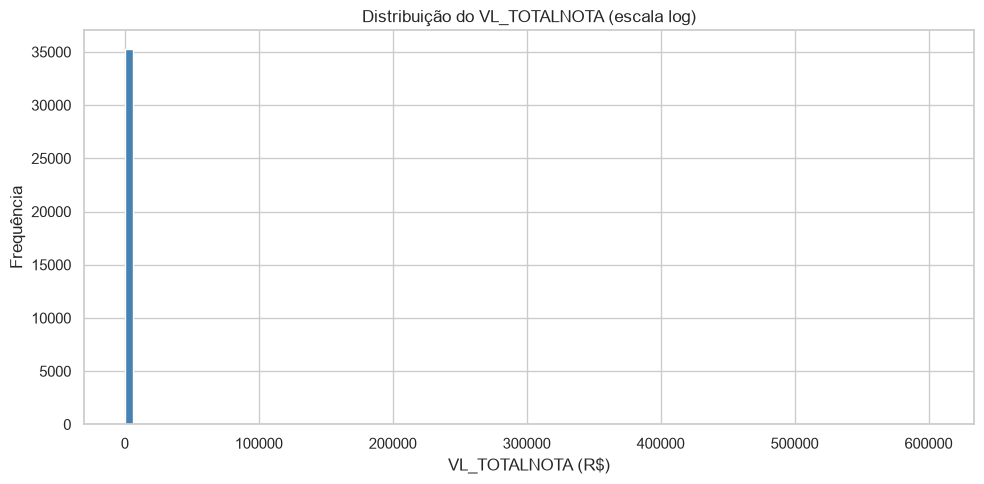

In [30]:
plt.figure(figsize=(10, 5))
plt.hist(df['VL_TOTALNOTA'][df['VL_TOTALNOTA'] > 0], bins=100, color='steelblue', edgecolor='white')
# plt.xscale('log')
plt.title('Distribuição do VL_TOTALNOTA (escala log)')
plt.xlabel('VL_TOTALNOTA (R$)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

### Boxplot do VL_TOTALNOTA

Boxplot em escala log para destacar a mediana, os quartis e a grande quantidade de outliers de alto valor, já identificados nas estatísticas descritivas (máximo de R$ 603.747,77).

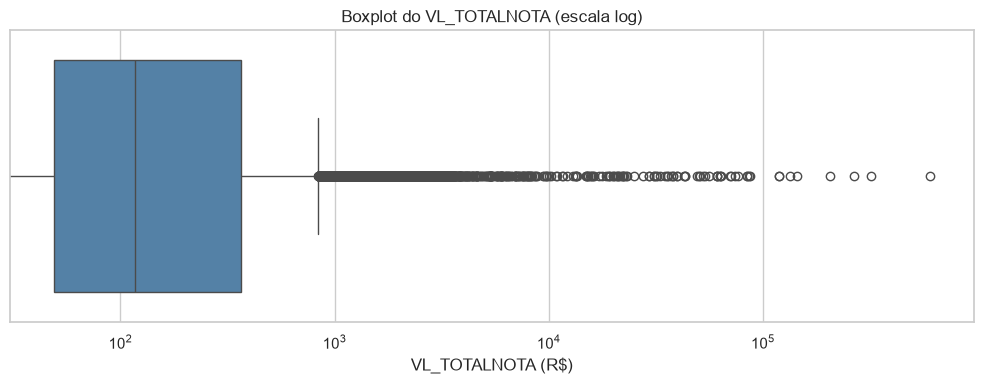

In [31]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['VL_TOTALNOTA'], color='steelblue')
plt.xscale('log')
plt.title('Boxplot do VL_TOTALNOTA (escala log)')
plt.xlabel('VL_TOTALNOTA (R$)')
plt.tight_layout()
plt.show()

### Distribuição da QT_FATURADO

Histograma em escala log no eixo Y para visualizar a concentração de quantidades faturadas nas notas, que em sua maioria são iguais a 1 ou 2, com outliers chegando a 1.527.

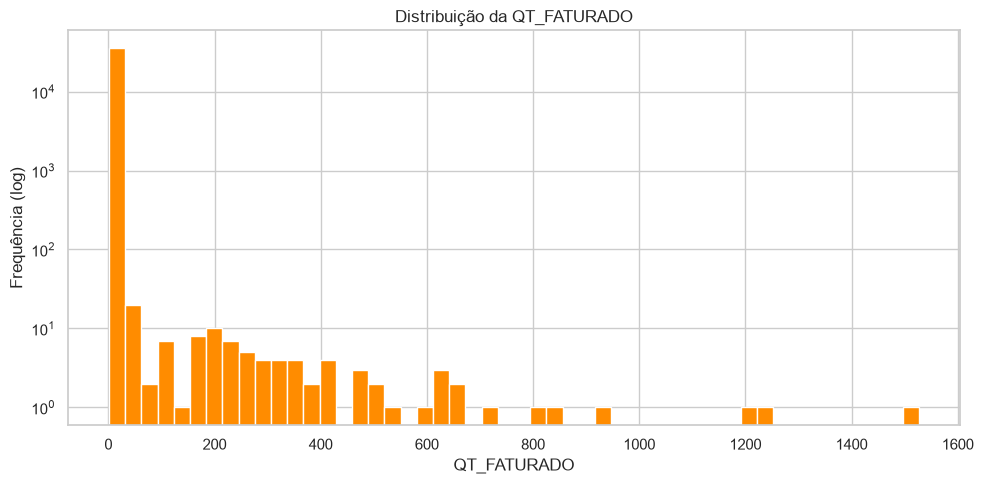

In [32]:
plt.figure(figsize=(10, 5))
plt.hist(df['QT_FATURADO'], bins=50, color='darkorange', edgecolor='white')
plt.yscale('log')
plt.title('Distribuição da QT_FATURADO')
plt.xlabel('QT_FATURADO')
plt.ylabel('Frequência (log)')
plt.tight_layout()
plt.show()

### Série temporal de faturamento (VL_TOTALNOTA por DT_FATURA)

O gráfico mostra a evolução diária do valor total das notas faturadas. `DT_FATURA` foi identificada como a melhor referência temporal por acompanhar o ciclo efetivo de faturamento, e a série permite identificar tendências e picos no período coberto pela base.

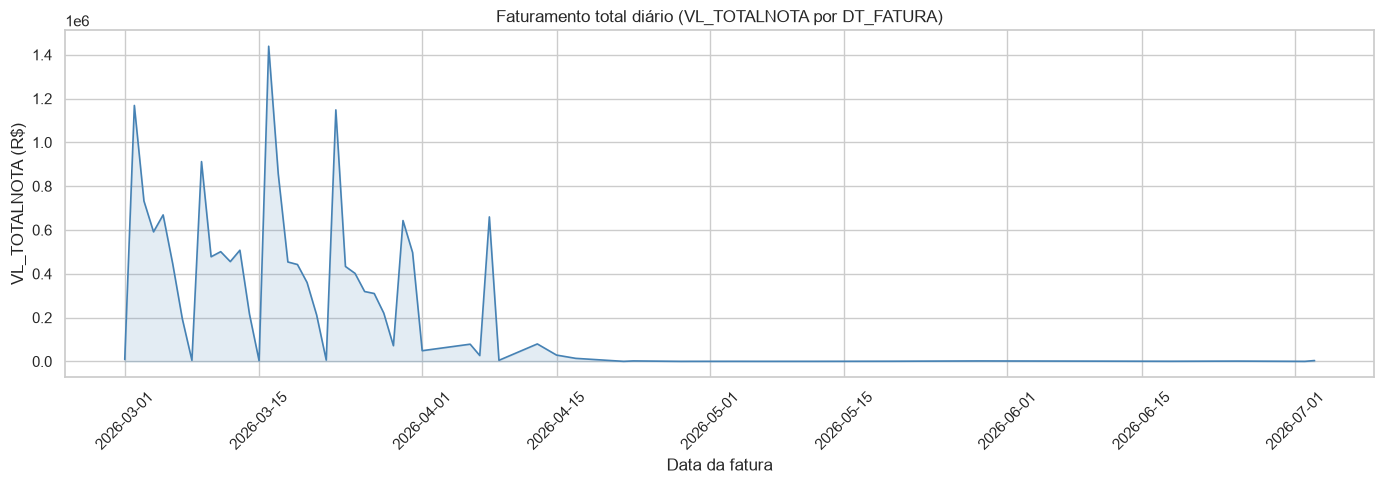

In [33]:
fat_diario = df.groupby('DT_FATURA')['VL_TOTALNOTA'].sum()

plt.figure(figsize=(14, 5))
plt.plot(fat_diario.index, fat_diario.values, color='steelblue', linewidth=1.2)
plt.fill_between(fat_diario.index, fat_diario.values, alpha=0.15, color='steelblue')
plt.title('Faturamento total diário (VL_TOTALNOTA por DT_FATURA)')
plt.xlabel('Data da fatura')
plt.ylabel('VL_TOTALNOTA (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Avaliando prefixo ```TP``` 

In [34]:
cols_tp = [c for c in df.columns if 'TP' in c.upper()]

for col in cols_tp:
    print(col)
    print(df[col].unique())
    print("="*50, '\n')

TP_ORIGEMEMISSAO
[2 1]

TP_MODDCTOFISCAL
[57 55 81]

TP_OPERACAO
<StringArray>
['E', 'S']
Length: 2, dtype: str

TP_SITUACAO
<StringArray>
['E', 'C', 'X']
Length: 3, dtype: str



In [35]:
for col in cols_tp:
    print(df[col].value_counts(normalize=True).mul(100).sort_values(ascending=False) , '\n')

TP_ORIGEMEMISSAO
1    52.284407
2    47.715593
Name: proportion, dtype: float64 

TP_MODDCTOFISCAL
55    52.561134
57    46.831761
81     0.607105
Name: proportion, dtype: float64 

TP_OPERACAO
E    52.702321
S    47.297679
Name: proportion, dtype: float64 

TP_SITUACAO
E    97.323093
X     1.524821
C     1.152087
Name: proportion, dtype: float64 



As colunas com prefixo ```TP``` indicam claramente referenciar a ```TIPO``` de alguma coisa, e trazem alguns pontos interessantes. 

- ```TP_MODDCTOFISCAL``` aparenta ser algum código interno para indicar o Modelo do Documento Fiscal. 

- ```TP_OPERACAO``` indica claramente o tipo de operação como sendo Entrada e Saída.

- ```TP_SITUACAO```  eu vou inferir que o significado dos dados são Executada/Válida (E), Excluído/Inválido (X), Cancelado (C).

- ```TP_ORIGEMEMISSAO``` de acordo com o nome indica a origem, mas ainda não fico claro, vamos fazer alguns cruzamentos de dados para tentar identificar.
  
De todas essas colunas, apenas ```TP_SITUACAO``` que contém os dados agregados em sua grande maioria em um único tipo de registro. As demais colunas apresentam uma distribuição quase uniforme.

### Distribuição TP_SITUACAO

Gráfico de barras mostrando que a grande maioria dos registros está em situação E (Executada/Válida), com uma pequena parcela de X (Excluído) e C (Cancelado).

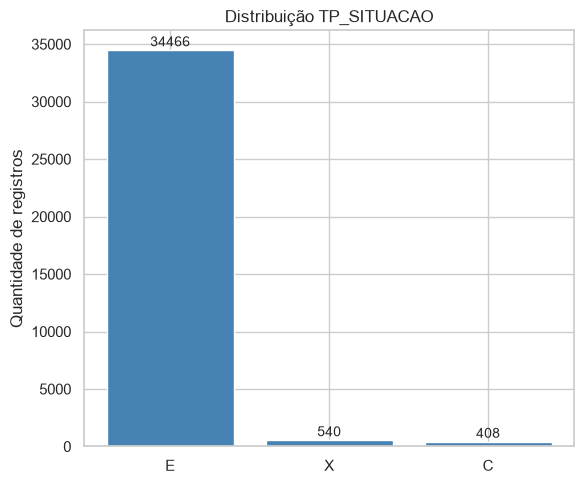

In [36]:
sit_counts = df['TP_SITUACAO'].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(sit_counts.index, sit_counts.values, color='steelblue', edgecolor='white')
plt.title('Distribuição TP_SITUACAO')
plt.ylabel('Quantidade de registros')
for i, v in enumerate(sit_counts.values):
    plt.text(i, v + max(sit_counts.values)*0.01, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### Distribuição TP_OPERACAO

Distribuição entre Entrada (E) e Saída (S), evidenciando que as saídas têm maior participação que as entradas na base de notas fiscais.

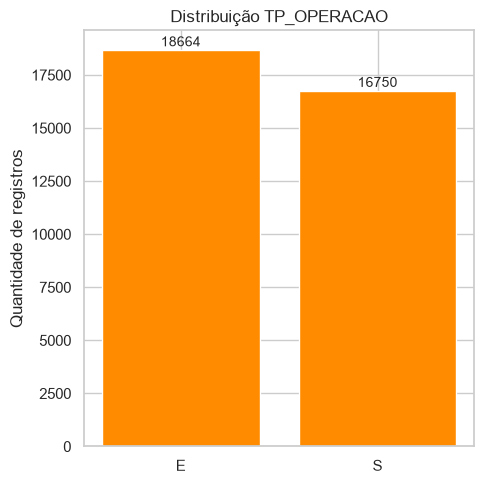

In [37]:
op_counts = df['TP_OPERACAO'].value_counts()

plt.figure(figsize=(5, 5))
plt.bar(op_counts.index, op_counts.values, color='darkorange', edgecolor='white')
plt.title('Distribuição TP_OPERACAO')
plt.ylabel('Quantidade de registros')
for i, v in enumerate(op_counts.values):
    plt.text(i, v + max(op_counts.values)*0.01, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### Distribuição TP_MODDCTOFISCAL

O gráfico mostra os três tipos documentais (55, 57, 81), evidenciando que 55 é o mais frequente, seguido de 57 com volume expressivo, e 81 com presença residual.

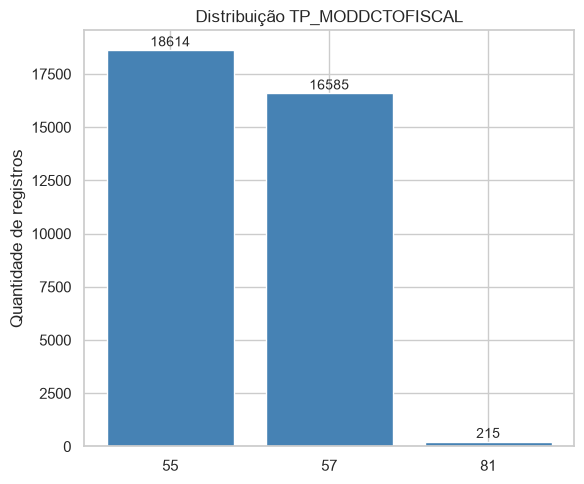

In [38]:
mod_counts = df['TP_MODDCTOFISCAL'].value_counts().sort_index()

plt.figure(figsize=(6, 5))
plt.bar(mod_counts.index.astype(str), mod_counts.values, color='steelblue', edgecolor='white')
plt.title('Distribuição TP_MODDCTOFISCAL')
plt.ylabel('Quantidade de registros')
for i, v in enumerate(mod_counts.values):
    plt.text(i, v + max(mod_counts.values)*0.01, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### Distribuição TP_ORIGEMEMISSAO

Distribuição entre as origens de emissão (1 e 2), mostrando uma distribuição quase uniforme entre as duas origens.

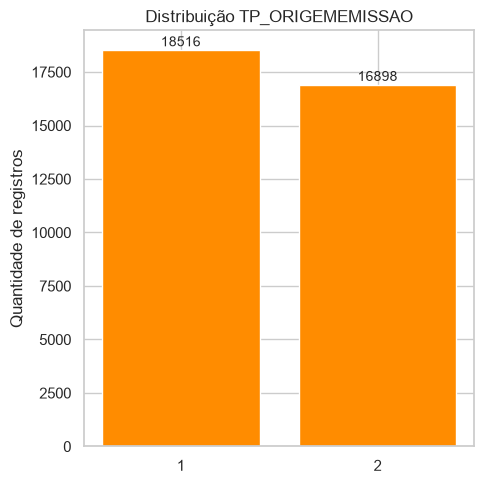

In [39]:
orig_counts = df['TP_ORIGEMEMISSAO'].value_counts().sort_index()

plt.figure(figsize=(5, 5))
plt.bar(orig_counts.index.astype(str), orig_counts.values, color='darkorange', edgecolor='white')
plt.title('Distribuição TP_ORIGEMEMISSAO')
plt.ylabel('Quantidade de registros')
for i, v in enumerate(orig_counts.values):
    plt.text(i, v + max(orig_counts.values)*0.01, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [40]:
pd.crosstab(df['TP_ORIGEMEMISSAO'], df['TP_OPERACAO'])

In [41]:
pd.crosstab(df['TP_ORIGEMEMISSAO'], df['TP_SITUACAO'])

In [42]:
pd.crosstab(df['TP_MODDCTOFISCAL'], df['TP_SITUACAO'])

In [43]:
pd.crosstab(df['TP_MODDCTOFISCAL'], df['TP_OPERACAO'])

In [44]:
pd.crosstab(df['TP_SITUACAO'], df['TP_OPERACAO'])

In [45]:
pd.crosstab(df['TP_SITUACAO'], df['TP_MODDCTOFISCAL'])

### Heatmap: TP_MODDCTOFISCAL x TP_OPERACAO

O cruzamento evidencia que o tipo documental 55 aparece tanto em entrada quanto saída (predominando saída), enquanto 57 e 81 são exclusivamente de entrada, reforçando a leitura dos três macroblocos documentais.

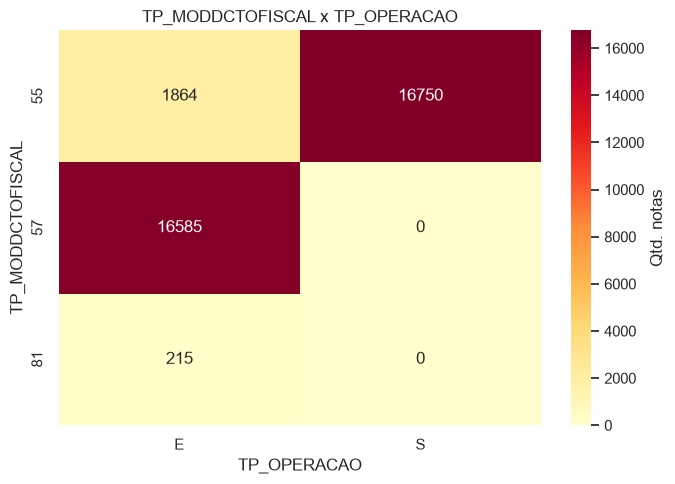

In [46]:
ct1 = pd.crosstab(df['TP_MODDCTOFISCAL'], df['TP_OPERACAO'])

plt.figure(figsize=(7, 5))
sns.heatmap(ct1, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Qtd. notas'})
plt.title('TP_MODDCTOFISCAL x TP_OPERACAO')
plt.tight_layout()
plt.show()

### Heatmap: TP_MODDCTOFISCAL x TP_SITUACAO

A tabela mostra a distribuição de situação (E, C, X) dentro de cada tipo documental. O tipo 55 concentra todos os cancelamentos (C), enquanto o tipo 57 tem uma parcela relevante de excluídos (X).

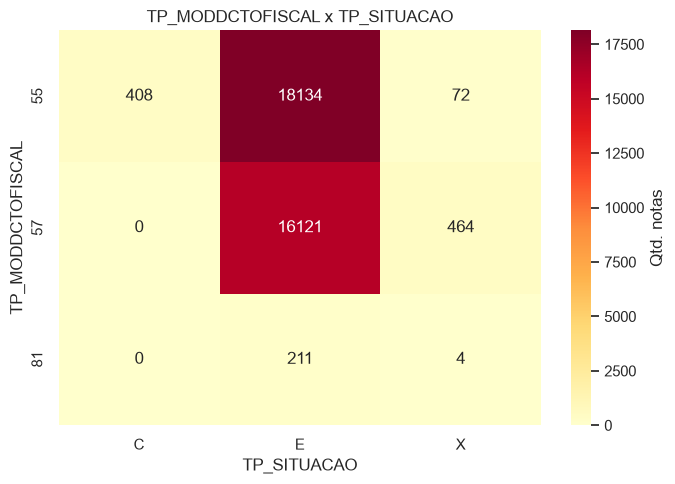

In [47]:
ct2 = pd.crosstab(df['TP_MODDCTOFISCAL'], df['TP_SITUACAO'])

plt.figure(figsize=(7, 5))
sns.heatmap(ct2, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Qtd. notas'})
plt.title('TP_MODDCTOFISCAL x TP_SITUACAO')
plt.tight_layout()
plt.show()

### Heatmap: TP_SITUACAO x TP_OPERACAO

O cruzamento entre situação e operação confirma que a grande maioria dos registros está em situação E (Executada/Válida), com poucos cancelamentos concentrados em saídas.

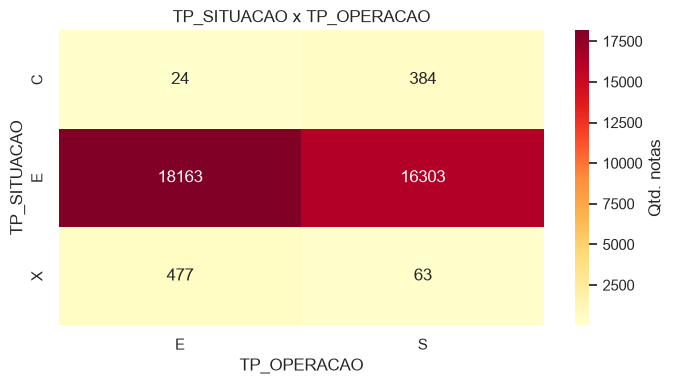

In [48]:
ct3 = pd.crosstab(df['TP_SITUACAO'], df['TP_OPERACAO'])

plt.figure(figsize=(7, 4))
sns.heatmap(ct3, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Qtd. notas'})
plt.title('TP_SITUACAO x TP_OPERACAO')
plt.tight_layout()
plt.show()

## Avaliando prefixo ```CD``` 

In [49]:
cols_cd = [c for c in df.columns if 'CD' in c.upper()]

for col in cols_cd:
    print(col)
    print(df[col].unique())
    print("="*50,'\n')

CD_EMPRESA
[6]

CD_PESSOA
[1738191 2067439 2477869 ... 2488672 2488683 2488685]

CD_EMPFAT
[6]

CD_GRUPOEMPRESA
[6]

CD_OPERADOR
[11032 11106 11134   831   557 11148 11120   465 11118  1173 11159  1161
  1132  1148 11145   927   933  1138  1180  1129   939   468 11124  1172
  1176   922   598   589   457 11142  1174  3356  1183  1175 11171 11139
 11127  1181 11122  1184   600 11062  1116 11059   638]

CD_SERIE
[  1  10   9   2  14   0 157   4   3  60  36   5  40  20  28   8  22   6
  51]

CD_EMPRESAORI
[6]

CD_OPERACAO
[1353 1300 5110 1994 1355 1933 9998   46 1354 1600 1601  231  233 5920
  560 1800  237  499 9143  408 5950 1982  410 5108  129 1949 2911  306
 9950  716]

CD_CONDPGTO
[   2   72   21  535  533  510  532  531  506   45   82  509  534  508
  507  536  505  503  501   37  585  586  540  504  348  502   83   18
  512  515  511    1  550  530   80 5591 5593    3  999]

CD_COMPVEND
[  3 854  60 788  89 890 852 856  69  50 855 889 577  56 857 865 150 758
  96  51]



In [50]:
for col in cols_cd:
    print(f'Quantidade de dados únicos em {col} -> {df[col].nunique()}')
    print(df[col].value_counts(normalize=True).mul(100).sort_values(ascending=False) , '\n')

Quantidade de dados únicos em CD_EMPRESA -> 1
CD_EMPRESA
6    100.0
Name: proportion, dtype: float64 

Quantidade de dados únicos em CD_PESSOA -> 16046
CD_PESSOA
1738191    8.013780
1905365    6.672502
2067439    5.469588
1720944    3.196476
2485702    2.806800
             ...   
2476131    0.002824
2102344    0.002824
2476132    0.002824
2476133    0.002824
2488685    0.002824
Name: proportion, Length: 16046, dtype: float64 

Quantidade de dados únicos em CD_EMPFAT -> 1
CD_EMPFAT
6    100.0
Name: proportion, dtype: float64 

Quantidade de dados únicos em CD_GRUPOEMPRESA -> 1
CD_GRUPOEMPRESA
6    100.0
Name: proportion, dtype: float64 

Quantidade de dados únicos em CD_OPERADOR -> 45
CD_OPERADOR
11134    30.764669
11106    14.432145
11120    13.497487
927      11.865364
933      10.902468
831       4.108545
11032     3.908059
1161      1.863670
11059     1.338454
11124     1.228328
465       0.722878
11159     0.632518
598       0.561925
11145     0.553453
1129      0.533687
11171    

Para colunas com prefixo ```CD``` 

Algumas contam com o mesmo padrão que foi identificado no arquivo ```NFITEM```, como por exemplo as colunas relacionadas à empresa, ```CD_EMPRESA```, ```CD_EMPFAT``` e ```CD_GRUPOEMPRESA```. Todas com um único registro, indicando que a base de dados é referente a apenas uma das empresas do grupo.

Já as outras colunas indicam ser algum tipo de nomenclatura interna da empresa, algumas são possíveis de inferir o que indicam, mas de qualquer forma será necessário cruzar algumas informaçōes para obter insights relevantes a respeito do conteúdo dessas colunas.

- ```CD_PESSOA``` contém 16046 registros únicos, sendo que o registro de maior frequência aparece em 8% dos dados. Essa coluna pode indicar um código ligado a um cliente/cadastro. 

- ```CD_SERIE``` contém 19 registros únicos porém a maioria dos dados estão concentrados nos códigos 1 e 2.

- ```CD_OPERADOR``` contém 45 registros únicos com a maioria dos dados concentrados em apenas 5 deles.

- ```CD_OPERACAO``` contém 30 registros únicos com a maioria dos dados concentrados em apenas 3 deles.

- ```CD_CONDPGTO``` contém 39 registros únicos com a maioria dos dados concentrados em apenas 4 deles.

- ```CD_COMPVEND``` contém 20 registros únicos com a maioria dos dados concentrados em apenas 2 deles.


Todos esses códigos não vão trazer grandes informaçōes se forem observados de forma isolada. Para conseguir mais informação desses dados será necessário cruzar com outras colunas para ver como eles se encaixam.

### Cardinalidade das colunas com prefixo CD

O gráfico mostra quantos valores únicos cada coluna `CD` possui. Colunas com apenas 1 valor único (`CD_EMPRESA`, `CD_EMPFAT`, `CD_GRUPOEMPRESA`, `CD_EMPRESAORI`) não agregam segmentação. Já `CD_PESSOA` (16.046 únicos) e `NR_NF` são identificadores individuais.

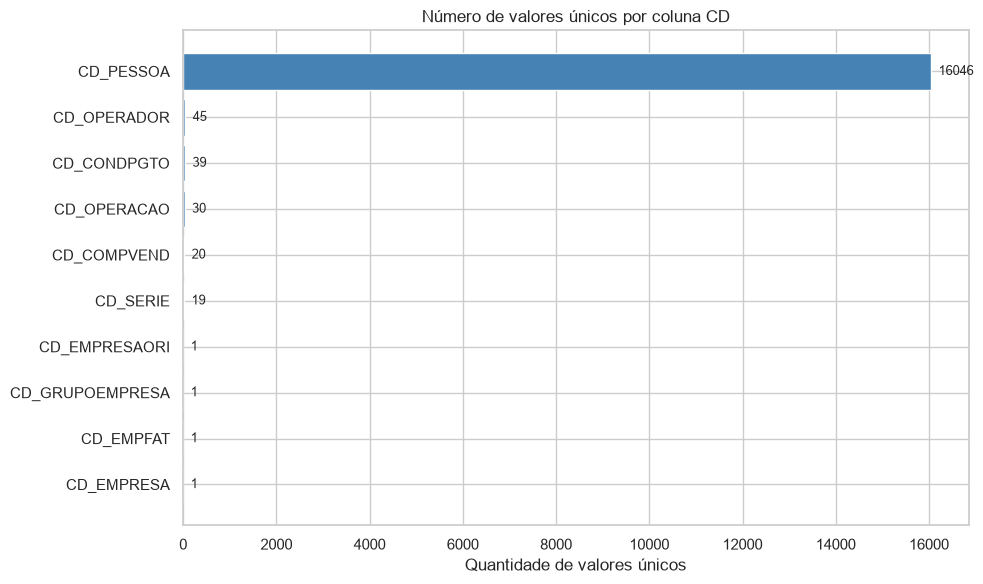

In [51]:
cols_cd = [c for c in df.columns if 'CD' in c.upper()]
cardinalidade = {col: df[col].nunique() for col in cols_cd}
card_serie = pd.Series(cardinalidade).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(card_serie.index, card_serie.values, color='steelblue', edgecolor='white')
plt.title('Número de valores únicos por coluna CD')
plt.xlabel('Quantidade de valores únicos')
for i, v in enumerate(card_serie.values):
    plt.text(v + max(card_serie.values)*0.01, i, str(int(v)), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Cruzando informaçōes

### Começar pelo bloco estrutural do documento

Esse é o melhor ponto de partida porque ele conecta:

- TP_MODDCTOFISCAL
- TP_OPERACAO
- TP_SITUACAO
- CD_SERIE
- NR_NF

A ideia aqui é entender:

- Que tipos de documento existem.
- Quais são de entrada e quais são de saída.
- Quais concentram cancelamentos/exclusões.
- Se a série separa tipos documentais ou fluxos.

In [52]:
pd.crosstab(
    df['TP_MODDCTOFISCAL'],
    [df['TP_OPERACAO'], df['TP_SITUACAO']]
)

O código 55 aparece em entrada e saída:

- E / E = 1831
- S / E = 16303
- além de alguns casos C e X

Isso mostra que o 55 é o tipo documental mais “geral” da base, porque participa dos dois fluxos:

- saída, com peso muito maior;
- entrada, com volume menor, mas ainda relevante.

A leitura mais provável é que o 55 esteja ligado ao documento fiscal principal de mercadoria. Não dá para cravar oficialmente só pelos dados, mas a distribuição é bem compatível com isso.

O mais importante aqui é: 55 não significa apenas venda. Ele aparece também em entrada. Então, para análise futura TP_MODDCTOFISCAL = 55 não pode ser tratado sinônimo automático de faturamento.

O 57 aparece somente em entrada:

- E / E = 16121
- E / X = 464
- nenhum caso em saída

Isso é um padrão muito limpo, pois sugere fortemente que o 57 representa um documento que, neste recorte, está sendo tratado como documento de entrada. Pelo que foi observado em NFITEM, isso conversa muito bem com os lançamentos de:

- frete.
- serviço de transporte.
- itens sem TIPI de produto clássico.

Então a inferência mais forte aqui é que 57 parece ser um tipo documental ligado a transporte/serviço tomado, e não a faturamento de venda.

O 81 também aparece somente em entrada:

- E / E = 211
- E / X = 4

Ele é pequeno em volume, mas muito consistente no padrão. Como também é só entrada, ele parece representar outro tipo documental não comercial de saída. 

Pelo que apareceu antes, há uma boa chance de ele estar ligado a algum tipo de documento de serviço, possivelmente diferente do 57.

Na prática essa primeira tabela permite separar a base em três blocos documentais bem diferentes:

- 55 = documento híbrido, mas majoritariamente de saída
- 57 = documento exclusivamente de entrada
- 81 = documento exclusivamente de entrada

Ou seja, a estrutura documental do NF já começa a se dividir naturalmente entre:

- um bloco com cara de operação comercial de mercadoria;
- e dois blocos com cara de entrada de documentos acessórios / serviços.

In [53]:
pd.crosstab(
    df['CD_SERIE'],
    [df['TP_MODDCTOFISCAL'], df['TP_OPERACAO']]
)

Aqui a série começa a ganhar contexto. 

A principal conclusão dessa tabela é:

CD_SERIE não deve ser interpretado sozinho. O significado da série depende do par:

- TP_MODDCTOFISCAL
- TP_OPERACAO

##### Série 2

A série 2 é a mais importante da base dentro do 55:

- 55 / S = 16122
- 55 / E = 1241
- 57 / E = 284

Ela concentra o coração do fluxo de 55, especialmente o de saída. Isso sugere que:

- série 2 é a principal série operacional do documento 55.
- e provavelmente carrega o maior bloco do faturamento comercial.

Como ela também aparece em 55 / E, isso reforça uma ideia importante: a série não é “entrada” ou “saída” por si só. Ela precisa ser lida junto com o tipo documental e a operação.

##### Série 1

A série 1 também chama muita atenção:

- 57 / E = 10717
- 81 / E = 215
- 55 / E = 39

Aqui a história é diferente. A série 1 está fortemente associada a entrada, principalmente com 57.

Isso sugere que a série 1 funciona quase como uma série padrão para documentos de entrada não comerciais de saída.

##### Série 9

A série 9 é interessante porque aparece dos dois lados dentro do 55:

- 55 / E = 581
- 55 / S = 582
- 57 / E = 1

Ela parece ter um comportamento mais “espelhado” ou “misto”. Não domina a base, mas claramente não é uma série de uso único. Merece observação porque pode representar um fluxo operacional específico.

##### Séries 3, 4, 10, 14, 60 etc.

Essas séries aparecem com peso menor, mas ajudam a perceber uma coisa importante:

- várias séries estão concentradas em 57 / E.
- portanto, as séries também parecem funcionar como subgrupos do tipo documental.

Em especial:

- 10 / 57 / E = 2882
- 3 / 57 / E = 685
- 4 / 57 / E = 625
- 14 / 57 / E = 424

Ou seja, o 57 está distribuído em várias séries, mas quase sempre no mesmo perfil: entrada.

Na prática essa segunda tabela mostra que:

- CD_SERIE tem valor analítico.
- Deve ser interpretado junto com o tipo documental e a operação
- Não deve ser interpretado como identificador isolado de natureza da nota.

Em outras palavras, a série ajuda a segmentar o fluxo, mas não define sozinha o que a nota representa.

In [54]:
(
    df.groupby(['CD_SERIE', 'TP_MODDCTOFISCAL', 'TP_OPERACAO'])
      .agg(
          QTD_NOTAS=('NR_FATURA', 'nunique'),
          VL_TOTALNOTA=('VL_TOTALNOTA', 'sum')
      )
      .sort_values('VL_TOTALNOTA', ascending=False)
)


```CD_SERIE = 2 / TP_MODDCTOFISCAL = 55 / TP_OPERACAO = S```

Esse é, claramente, o principal fluxo da base:

- 16122 notas com VL_TOTALNOTA = R$8.783.739,45
  
O grupo domina completamente o dataset e tem todo o perfil de ser o principal bloco comercial de saída.

```CD_SERIE = 2 / 55 / E```

Esse segundo bloco também é muito relevante:

- 1241 notas com VL_TOTALNOTA = R$1.836.484,74

É entrada com o mesmo tipo documental 55 e a mesma série principal. Isso sugere que parte relevante do ecossistema do 55 está associada a entrada, e não apenas a venda. Muito possivelmente esse bloco terá relação com:

- devoluções.
- entradas fiscais relacionadas ao mesmo tipo de documento.
- outros movimentos de regularização.

```CD_SERIE = 1 / 55 / E```

Esse é um caso muito importante:

- apenas 39 notas mas com VL_TOTALNOTA =  R$1.813.901,07

Ou seja, ticket médio altíssimo. Isso mostra que existem poucos documentos com muito valor agregado nesse fluxo. Eles merecem inspeção posterior, porque podem ser:

- documentos específicos de alto valor.
- ajustes.
- operações concentradas.
- algum tipo de entrada especial.

```CD_SERIE = 1 / 81 / E```

Outro bloco bem expressivo:

- 215 notas com VL_TOTALNOTA = R$1.745.364,77

É muito valor para pouco volume. Como 81 só aparece em entrada, esse grupo parece representar um fluxo de entrada bastante relevante financeiramente.

```CD_SERIE = 1 / 57 / E```

Esse bloco é o oposto em perfil:

- 10717 notas com VL_TOTALNOTA = R$754.475,98

Aqui o volume é muito alto e o valor médio é baixo. Isso casa bem com uma hipótese de documentos de frete / transporte / serviços acessórios de menor valor unitário.

```CD_SERIE = 9 / 55 / S```

- 582 notas com VL_TOTALNOTA = R$245.965,62

Parece um subfluxo menor de saída do documento 55.

```CD_SERIE = 10 / 57 / E```

2882 notas com VL_TOTALNOTA = R$146.827,69

Outro subfluxo de entrada associado ao 57, com bastante volume e valor médio mais baixo.

```Demais grupos```

Os outros grupos têm menos peso relativo, mas confirmam o padrão geral:

- 57 está pulverizado em várias séries, sempre em entrada;
- 55 concentra o grande fluxo de saída;
- 81 aparece de forma pequena em volume, mas forte em valor.

### VL_TOTALNOTA por combinação CD_SERIE / TP_MODDCTOFISCAL / TP_OPERACAO

O gráfico mostra o valor total das notas para as principais combinações de série, tipo documental e operação, evidenciando o domínio do fluxo `S2 / 55 / S` (saída comercial principal) e a relevância do fluxo `S1 / 55 / E` com alto ticket médio.

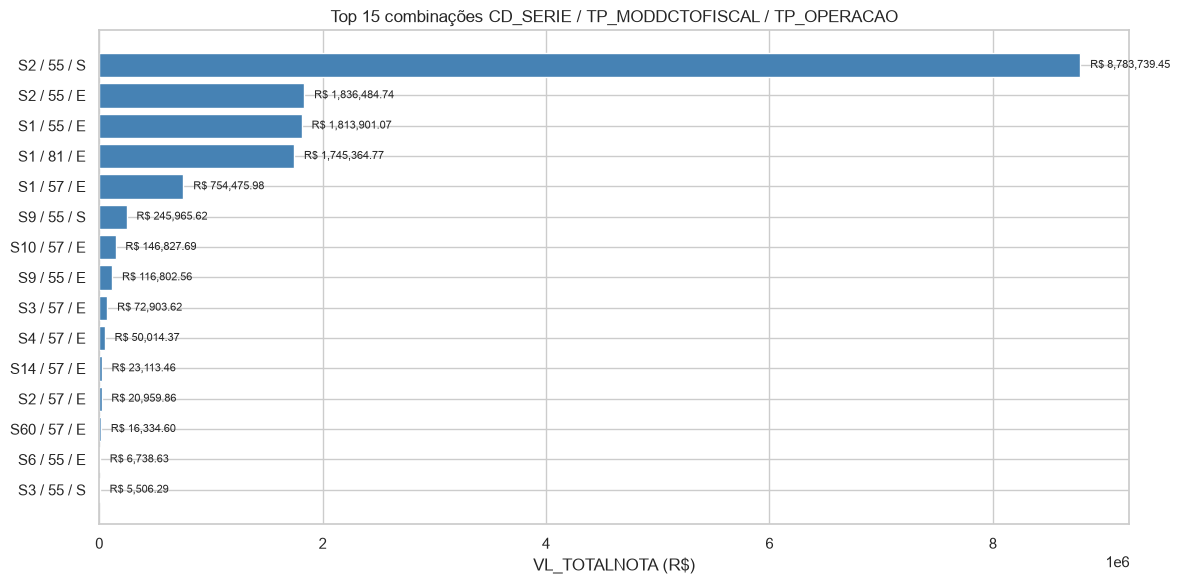

In [55]:
combos = (
    df.groupby(['CD_SERIE', 'TP_MODDCTOFISCAL', 'TP_OPERACAO'])
      .agg(VL_TOTALNOTA=('VL_TOTALNOTA', 'sum'),
           QTD_NOTAS=('NR_FATURA', 'nunique'))
      .sort_values('VL_TOTALNOTA', ascending=False)
      .head(15)
)

labels = [f'S{int(idx[0])} / {int(idx[1])} / {idx[2]}' for idx in combos.index]
plt.figure(figsize=(12, 6))
plt.barh(labels[::-1], combos['VL_TOTALNOTA'].values[::-1], color='steelblue', edgecolor='white')
plt.title('Top 15 combinações CD_SERIE / TP_MODDCTOFISCAL / TP_OPERACAO')
plt.xlabel('VL_TOTALNOTA (R$)')
for i, v in enumerate(combos['VL_TOTALNOTA'].values[::-1]):
    plt.text(v + max(combos['VL_TOTALNOTA'])*0.01, i, f'R$ {v:,.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

#### Leitura consolidada dos resultados até aqui

1. O dataset de NF tem três macroblocos documentais.
- 55: bloco principal, majoritariamente de saída, mas com entradas relevantes.
- 57: bloco exclusivamente de entrada, muito volumoso e com cara de documentos acessórios/serviços/transporte
- 81: bloco exclusivamente de entrada, pequeno em volume e forte em valor.
  
2. A série ajuda a segmentar esses blocos
- série 2 domina o fluxo principal do 55
- série 1 domina boa parte dos fluxos de entrada em 57 e 81
- outras séries parecem funcionar como subcanais ou subtipos documentais

3. O fluxo comercial principal provavelmente está em 55 / S / SERIE 2
- Esse é o melhor candidato ao núcleo de faturamento de saída.

4. Há blocos de entrada relevantes que não podem ser ignorados

Especialmente:

- 55 / E
- 57 / E
- 81 / E

#### Hipóteses

- TP_MODDCTOFISCAL 55 = documento principal de mercadoria, com saída dominante
- TP_MODDCTOFISCAL 57 = documento de entrada ligado a transporte/serviço/acessório
- TP_MODDCTOFISCAL 81 = documento de entrada ligado a serviço específico, provavelmente de maior valor médio
- CD_SERIE 2 = principal série do fluxo comercial de saída
- CD_SERIE 1 = principal série de entradas de 57 e 81

### Entrar no bloco operacional

Aqui o foco passa a ser:

- CD_OPERACAO
- TP_OPERACAO
- TP_SITUACAO
- TP_MODDCTOFISCAL

Porque CD_OPERACAO parece ser uma das colunas mais explicativas do cabeçalho.

In [56]:
pd.crosstab(
    df['CD_OPERACAO'],
    [df['TP_OPERACAO'], df['TP_SITUACAO']]
)


Pelos cruzamentos, o ```CD_OPERACAO``` não parece um identificador aleatório. Ele parece ser um código operacional interno muito consistente, porque quase todo código cai sempre no mesmo padrão de:

- entrada ou saída.
- tipo documental.
- em muitos casos, um comportamento financeiro bem específico.

A melhor evidência disso está na tabela acima:

- vários códigos aparecem 100% em TP_OPERACAO = E
- outros aparecem 100% em TP_OPERACAO = S
- quase nenhum mistura entrada e saída ao mesmo tempo

Isso é ótimo, porque mostra que CD_OPERACAO pode virar uma dimensão muito útil na análise principal.

In [57]:
(
    df.groupby(['CD_OPERACAO', 'TP_OPERACAO', 'TP_SITUACAO'])
      .agg(
          QTD_NOTAS=('NR_FATURA', 'nunique'),
          VL_TOTALNOTA=('VL_TOTALNOTA', 'sum'),
          VL_TOTALPRODUTO=('VL_TOTALPRODUTO', 'sum')
      )
      .sort_values('VL_TOTALNOTA', ascending=False)
)


O cruzamento CD_OPERACAO x TP_OPERACAO x TP_SITUACAO mostra dois blocos muito nítidos.

1. Bloco de entrada (TP_OPERACAO = E)

Esse grupo parece representar:

- devoluções.
- entradas de serviço.
- entradas administrativas.
- ou outras entradas fiscais/operacionais.

2. Bloco de saída (TP_OPERACAO = S)

Esse grupo parece representar:

- vendas.
- saídas comerciais.
- algumas saídas específicas menores.

Então, antes mesmo de entender o significado exato de cada código, o dado já mostra que o CD_OPERACAO está muito alinhado com o sentido da movimentação.

In [58]:
pd.crosstab(
    df['CD_OPERACAO'],
    df['TP_MODDCTOFISCAL']
)


A tabela acima mostra que cada CD_OPERACAO está praticamente amarrado a um único TP_MODDCTOFISCAL.

```TP_MODDCTOFISCAL = 55``` -> Ficam aqui quase todos os códigos ligados ao fluxo principal de mercadoria, tanto entrada quanto saída.

Isso reforça a hipótese de que o 55 é o documento principal de mercadoria da base.

```TP_MODDCTOFISCAL = 57``` ->  Ficam aqui os grandes códigos de entrada operacionais.

Esse bloco já está com uma cara muito forte de:

- transporte.
- entradas acessórias.
- documentos operacionais de apoio.
- talvez conhecimento de transporte ou similares.

```TP_MODDCTOFISCAL = 81``` -> Aqui só aparece um registro.

Isso é muito forte. Significa que 1933 e 81 andam quase juntos como uma categoria própria. E como 1933 já lembra o CFOP de serviço, esse bloco pode estar ligado a serviço específico de entrada.

Em resumo: CD_OPERACAO e TP_MODDCTOFISCAL estão quase em relação de “família”.

---

### O que já dá para inferir com bastante segurança

Sem precisar cravar significados oficiais, o dado já sustenta algumas hipóteses fortes.

Hipóteses fortes

- 9998 = principal fluxo de saída comercial
- 46 = devolução / entrada ligada a devolução
- 1933 = serviço de entrada de alto valor, associado ao tipo documental 81
- 1300, 1355, 1600 = fluxos operacionais de entrada associados ao tipo documental 57
- 231, 233, 5110, 5920, 9143 = subfluxos de saída em 55

Hipóteses de atenção

- 499 = entrada de altíssimo valor, pouco volume,
- 9950 = caso isolado muito relevante, provavelmente excepcional
- 1982 = aparece cancelado apenas uma vez, mas com valor alto
- 560 = entrada pequena em volume e alta em valor relativo, merece olhar depois

### Quantidade de notas por CD_OPERACAO

O ranking dos códigos de operação por quantidade de notas evidencia a forte concentração em poucos códigos (9998, 1300, 1355, 1600).

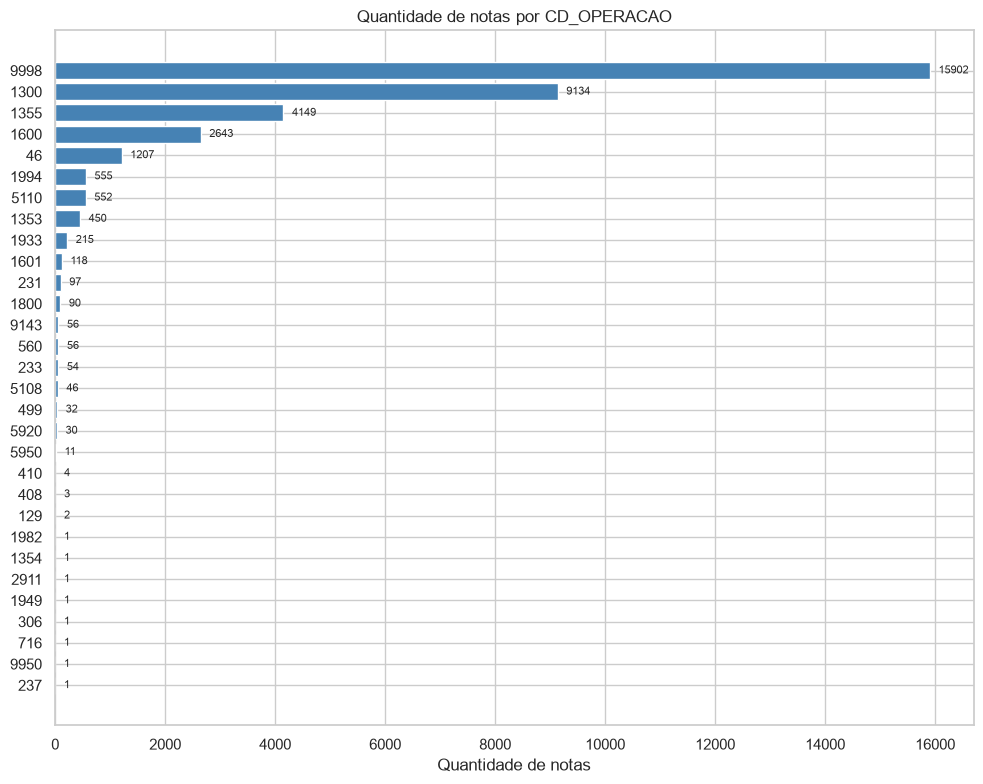

In [59]:
op_qtd = (
    df.groupby('CD_OPERACAO')
      .agg(QTD_NOTAS=('NR_FATURA', 'size'))
      .sort_values('QTD_NOTAS', ascending=False)
)

plt.figure(figsize=(10, 8))
plt.barh(op_qtd.index[::-1].astype(str), op_qtd['QTD_NOTAS'].values[::-1],
        color='steelblue', edgecolor='white')
plt.title('Quantidade de notas por CD_OPERACAO')
plt.xlabel('Quantidade de notas')
for i, v in enumerate(op_qtd['QTD_NOTAS'].values[::-1]):
    plt.text(v + max(op_qtd['QTD_NOTAS'])*0.01, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

### VL_TOTALNOTA por CD_OPERACAO

O valor total das notas por código de operação (escala log), destacando que o código 9998 domina o faturamento, enquanto códigos como 499, 1933 e 9950 têm alto valor apesar de baixo volume documental.

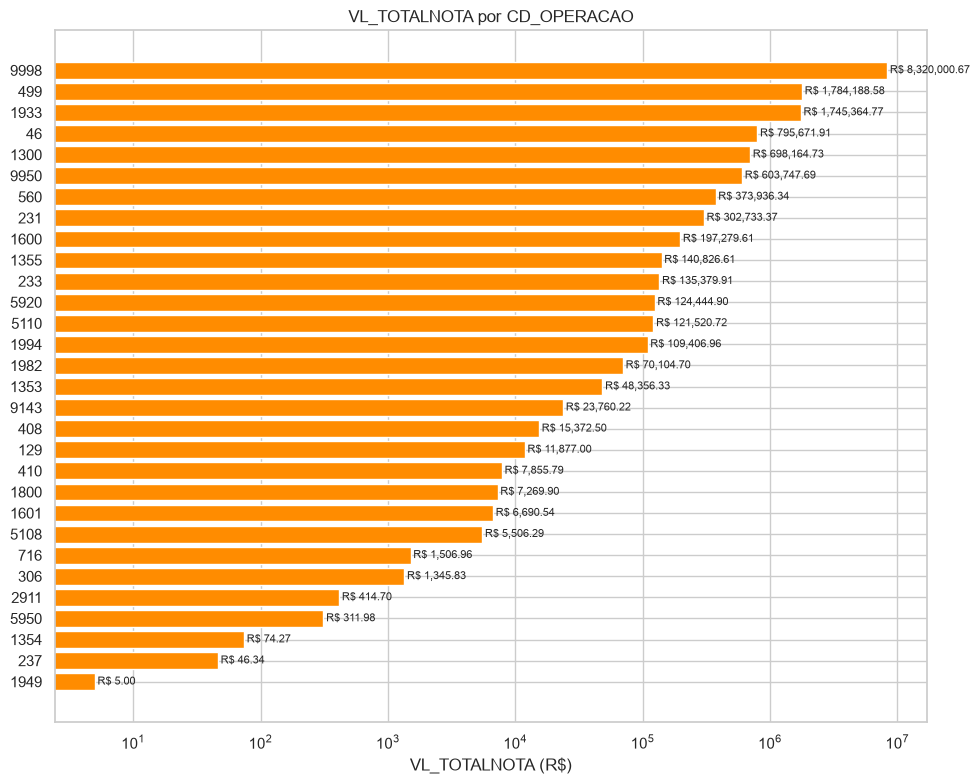

In [60]:
op_vl = (
    df.groupby('CD_OPERACAO')
      .agg(VL_TOTALNOTA=('VL_TOTALNOTA', 'sum'))
      .sort_values('VL_TOTALNOTA', ascending=False)
)

plt.figure(figsize=(10, 8))
plt.barh(op_vl.index[::-1].astype(str), op_vl['VL_TOTALNOTA'].values[::-1],
        color='darkorange', edgecolor='white')
plt.title('VL_TOTALNOTA por CD_OPERACAO')
plt.xlabel('VL_TOTALNOTA (R$)')
plt.xscale('log')
for i, v in enumerate(op_vl['VL_TOTALNOTA'].values[::-1]):
    plt.text(v * 1.05, i, f'R$ {v:,.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### Validar a identidade fiscal da nota

In [61]:
df[['NR_NF', 'CD_SERIE']].duplicated().sum()

np.int64(455)

In [62]:
df[['NR_NF', 'CD_SERIE', 'TP_MODDCTOFISCAL']].duplicated().sum()


np.int64(453)

In [63]:
(
    df.groupby('CD_SERIE')
      .agg(
          QTD_NOTAS=('NR_FATURA', 'nunique'),
          QTD_NR_NF=('NR_NF', 'nunique'),
          VL_TOTALNOTA=('VL_TOTALNOTA', 'sum')
      )
      .sort_values('VL_TOTALNOTA', ascending=False)
)


In [64]:
pd.crosstab(df['CD_SERIE'],df['TP_SITUACAO'])


A leitura mais importante aqui não é só “há duplicados”, mas sim que os duplicados parecem estruturados, não aleatórios.

A tabela por CD_SERIE ajuda muito a enxergar isso.

A primeira observação é a concentração. O campo é extremamente dominado por poucas séries:

- 2 → 17.647 notas, 10.641.184,05
- 1 → 10.971 notas, 4.313.741,82
- 10 → 2.882 notas, 146.827,69
- 9 → 1.164 notas, 363.284,60

Só essas quatro séries já concentram praticamente toda a base. Então CD_SERIE não é um campo irrelevante: ele claramente separa grandes blocos documentais.

Agora vem a parte mais interessante: a relação entre série, unicidade e situação.

Na série 2, há 17.647 notas e 17.647 números distintos de NF. 
- Dentro da série 2, o número da nota não se repete. Isso é muito forte. Mesmo existindo 408 canceladas e 71 excluídas, a numeração continua única. Isso sugere que, nessa série, cancelamento/exclusão não gera reaproveitamento aparente do número.

Na série 1, há 10.971 notas e 10.961 números distintos. 
- Aqui aparecem 10 repetições líquidas. Não é muito, mas já mostra que a série 1 não é perfeitamente única por NR_NF. E como nela existem 22 notas X, dá para dizer que parte dessas repetições pode estar ligada a documentos excluídos, mas não é uma correspondência perfeita.

Na série 10 há 2.882 notas e 2.438 números distintos.
- Diferença de 444. Padrão mais revelador.

E no cruzamento com situação:
- 2.438 em E
- 444 em X

Essa coincidência é forte demais para ser ignorada. A inferência mais natural é que a série 10 carrega um bloco em que os registros X explicam praticamente toda a não unicidade do NR_NF dentro da série.

Claramente a série 10 parece ter um comportamento em que muitos números válidos convivem com uma versão excluída do mesmo número, ou algum tipo de histórico/reprocessamento documental. Não estou cravando o mecanismo exato, mas o padrão estatístico aponta fortemente para isso.

A série 6 repete esse mesmo desenho em miniatura:

- 4 notas, 3 números distintos, 1 excluída

Ou seja, de novo, a não unicidade parece alinhada com X.

Isso muda bastante a leitura do campo. CD_SERIE não parece ser apenas um atributo formal do documento, ele está ajudando a separar comportamentos de emissão e qualidade cadastral.

Outro ponto bom de observar é o perfil financeiro das séries.

1. A série 2 é a mais pesada em volume e valor. Ela tem cara de série principal de operação. Além do volume gigantesco, é a única com cancelamento em massa relevante (408 em C). Isso normalmente acontece justamente nas séries centrais do negócio.

2. A série 1 também é grande e financeiramente forte, mas muito mais “limpa” em status:
    - sem canceladas
    - só 22 excluídas

Ela parece um segundo grande bloco operacional, mais estável que a série 2.

3. A série 10, por outro lado, tem muito volume para pouco valor:
    - 2.882 notas
    - R$146.827,69
    - O ticket médio é baixo. E junto com o excesso de X, isso faz ela parecer um fluxo mais administrativo, operacional ou documental, e menos um núcleo de faturamento principal.

4. A série 9 chama atenção por ser menor em quantidade, mas relativamente forte em valor. Ela pode ser um fluxo específico com ticket médio mais alto do que a série 10, embora bem menor do que as séries 1 e 2 em volume.

Também vale notar algumas séries estranhas pelo perfil financeiro:

- série 0: 751 notas para só R$5.281,78
- série 157: 21 notas para R$581,21
- série 60: 154 notas para R$16.334,60
- Essas séries pequenas podem representar fluxos muito específicos, ajustes, documentos acessórios ou operações residuais. Ainda não dá para interpretar semanticamente, mas elas claramente não têm o mesmo papel das séries 1, 2 e 10.

A melhor conclusão deste bloco, para mim, é esta:

- CD_SERIE é uma coluna útil, principalmente para segmentar fluxos documentais e detectar padrões de duplicidade/status.

O que ela já mostra com segurança é:

- NR_NF sozinho não serve como chave;
- NR_NF + CD_SERIE ainda não serve;
- NR_NF + CD_SERIE + TP_MODDCTOFISCAL quase não melhora;
- a duplicidade está fortemente concentrada em algumas séries, especialmente a 10;
- a série 10 parece ter associação muito forte com registros X;
- a série 2 parece ser a principal série operacional e concentra os cancelamentos;
- a série 1 é grande e relativamente limpa;

Portanto, CD_SERIE é um bom campo para entender comportamento documental, não necessariamente para classificar a operação final.

### Quantidade de notas por CD_SERIE

O gráfico evidencia a forte concentração de notas nas séries 2, 1 e 10, que juntas representam praticamente toda a base. A série 2 é a principal série operacional, com mais de 17 mil notas.

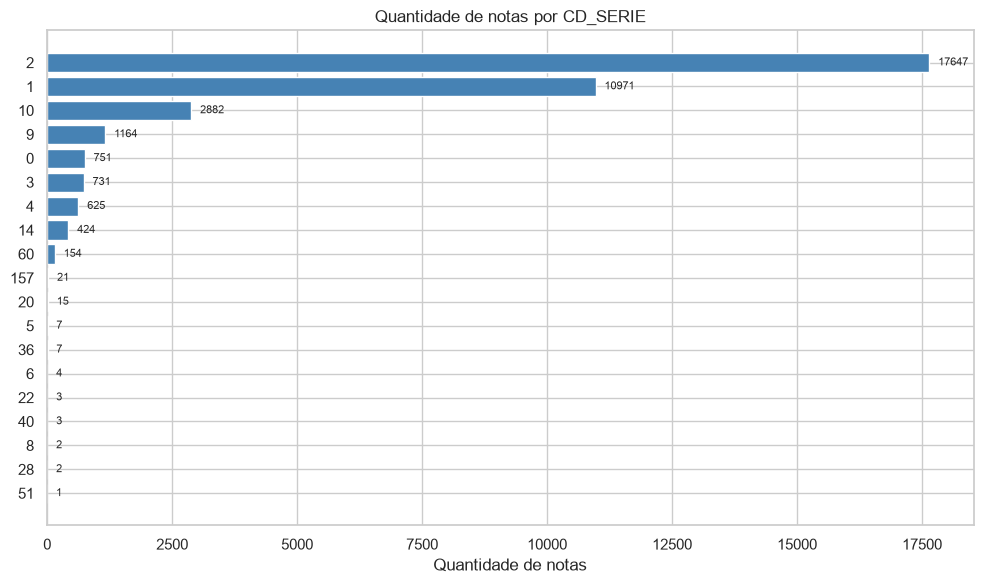

In [65]:
serie_qtd = (
    df.groupby('CD_SERIE')
      .agg(QTD_NOTAS=('NR_FATURA', 'nunique'))
      .sort_values('QTD_NOTAS', ascending=False)
)

plt.figure(figsize=(10, 6))
plt.barh(serie_qtd.index[::-1].astype(str), serie_qtd['QTD_NOTAS'].values[::-1],
        color='steelblue', edgecolor='white')
plt.title('Quantidade de notas por CD_SERIE')
plt.xlabel('Quantidade de notas')
for i, v in enumerate(serie_qtd['QTD_NOTAS'].values[::-1]):
    plt.text(v + max(serie_qtd['QTD_NOTAS'])*0.01, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

### VL_TOTALNOTA por CD_SERIE

O valor financeiro total por série, em escala logarítmica. A série 2 domina com mais de R$ 10 milhões, seguida da série 1 com R$ 4,3 milhões. As séries menores (0, 157, 60) têm valores residuais.

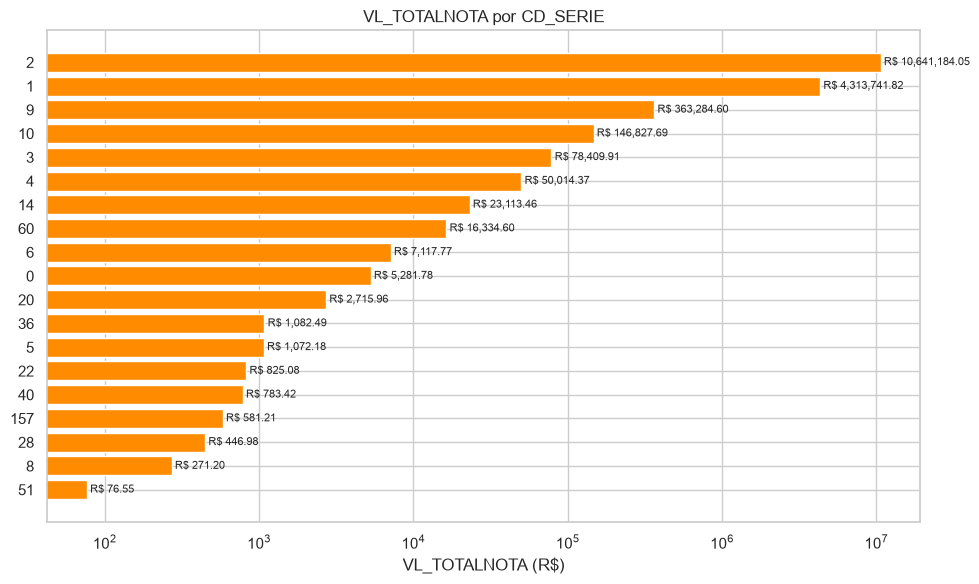

In [66]:
serie_vl = (
    df.groupby('CD_SERIE')
      .agg(VL_TOTALNOTA=('VL_TOTALNOTA', 'sum'))
      .sort_values('VL_TOTALNOTA', ascending=False)
)

plt.figure(figsize=(10, 6))
plt.barh(serie_vl.index[::-1].astype(str), serie_vl['VL_TOTALNOTA'].values[::-1],
        color='darkorange', edgecolor='white')
plt.title('VL_TOTALNOTA por CD_SERIE')
plt.xlabel('VL_TOTALNOTA (R$)')
plt.xscale('log')
for i, v in enumerate(serie_vl['VL_TOTALNOTA'].values[::-1]):
    plt.text(v * 1.05, i, f'R$ {v:,.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### Heatmap: CD_SERIE x TP_SITUACAO

O cruzamento entre série e situação mostra que a série 2 concentra todos os cancelamentos (C), enquanto a série 10 tem alta proporção de excluídos (X), reforçando a leitura de que cada série possui um comportamento documental distinto.

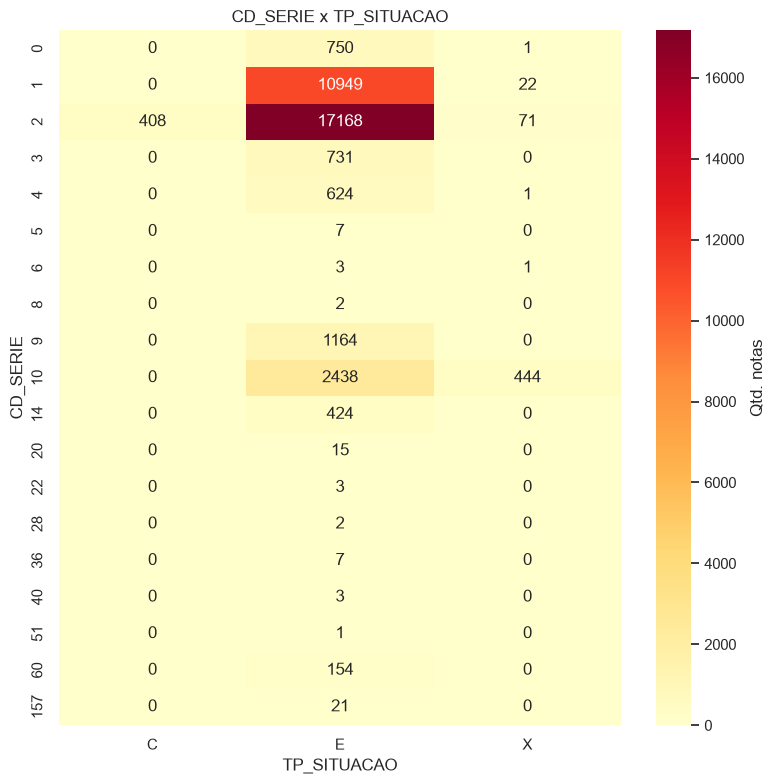

In [67]:
ct_serie_sit = pd.crosstab(df['CD_SERIE'], df['TP_SITUACAO'])

plt.figure(figsize=(8, 8))
sns.heatmap(ct_serie_sit, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Qtd. notas'})
plt.title('CD_SERIE x TP_SITUACAO')
plt.xlabel('TP_SITUACAO')
plt.ylabel('CD_SERIE')
plt.tight_layout()
plt.show()

In [68]:
df[['NR_NF', 'CD_SERIE']].duplicated().sum() == 455

np.True_

In [69]:
df[['NR_NF', 'CD_SERIE', 'TP_MODDCTOFISCAL']].duplicated().sum() == 453

np.True_

In [70]:
df[df['TP_SITUACAO'] == 'E'][['NR_NF', 'CD_SERIE']].duplicated().sum()


np.int64(5)

In [71]:
df[df['TP_SITUACAO'] == 'E'][['NR_NF', 'CD_SERIE', 'TP_MODDCTOFISCAL']].duplicated().sum()

np.int64(3)

##### Nota
Unicidade documental: relevante para métricas finais, mas parcialmente endereçada por enquanto. Após filtrar TP_SITUACAO = 'E', duplicidades caem de forma expressiva, restando poucos casos residuais.

## Avaliando prefixo ```DT``` 

In [72]:
cols_dt = [c for c in df.columns if 'DT' in c.upper() or 'DATA' in c.upper()]

for col in cols_dt:
    print(col)
    print(df[col].dtypes)
    print(df[col].isna().sum())
    print(df[col].agg(['min','max']))
    print(df[col].value_counts(normalize=True).mul(100).sort_index())
    print('='*50, '\n')

DT_FATURA
datetime64[us]
0
min   2026-03-01
max   2026-07-03
Name: DT_FATURA, dtype: datetime64[us]
DT_FATURA
2026-03-01    0.093183
2026-03-02    4.272322
2026-03-03    2.837861
2026-03-04    1.891907
2026-03-05    1.615180
2026-03-06    1.863670
2026-03-07    0.830180
2026-03-08    0.096007
2026-03-09    5.624894
2026-03-10    2.640199
2026-03-11    2.400181
2026-03-12    2.199695
2026-03-13    6.709211
2026-03-14    1.005252
2026-03-15    0.062122
2026-03-16    5.017790
2026-03-17    3.651098
2026-03-18    3.394138
2026-03-19    3.171062
2026-03-20    3.882645
2026-03-21    0.892302
2026-03-22    0.112950
2026-03-23    4.969786
2026-03-24    4.828599
2026-03-25    4.743887
2026-03-26    2.129101
2026-03-27    2.044389
2026-03-28    1.649065
2026-03-29    0.705936
2026-03-30    6.048455
2026-03-31    4.136782
2026-04-01    1.462698
2026-04-06    2.451008
2026-04-07    0.940306
2026-04-08    5.785847
2026-04-09    0.033885
2026-04-13    2.442537
2026-04-15    0.717230
2026-04-17    0.

In [73]:
cols_data = ['DT_FATURA', 'DT_EMISSAO', 'DT_SAIDAENTRADA']

for col in cols_data:
    print(f'\n{col}')
    print(
        df.groupby(df[col].dt.date)
          .agg(
              QTD_NOTAS=('NR_NF', 'size'),
              VL_TOTALNOTA=('VL_TOTALNOTA', 'sum')
          )
          .head()
    )
    print('...')
    print(
        df.groupby(df[col].dt.date)
          .agg(
              QTD_NOTAS=('NR_NF', 'size'),
              VL_TOTALNOTA=('VL_TOTALNOTA', 'sum')
          )
          .tail()
    )



DT_FATURA
            QTD_NOTAS  VL_TOTALNOTA
DT_FATURA                          
2026-03-01         33       8726.70
2026-03-02       1513    1168687.92
2026-03-03       1005     732282.53
2026-03-04        670     591429.77
2026-03-05        572     668887.81
...
            QTD_NOTAS  VL_TOTALNOTA
DT_FATURA                          
2026-05-29         31       1967.54
2026-06-18          6        475.79
2026-06-25         31       1264.01
2026-07-02          1         44.53
2026-07-03         61       3910.21

DT_EMISSAO
            QTD_NOTAS  VL_TOTALNOTA
DT_EMISSAO                         
2026-03-01         50      98789.67
2026-03-02       2323    1365833.23
2026-03-03       2090     864146.39
2026-03-04       1460    1041935.59
2026-03-05       1133     644507.16
...
            QTD_NOTAS  VL_TOTALNOTA
DT_EMISSAO                         
2026-03-27        864     310023.85
2026-03-28        788     227739.77
2026-03-29        579      79279.68
2026-03-30       1662     626045.

#### Data base - Relatório de Faturamento

Para seguir com a análise, a data de referência utilizada no relatório vai ser DT_EMISSAO.

## Avaliando prefixo ```VL``` 

In [74]:
cols_vl = [col for col in df.columns if col.upper().startswith('VL')]

df[cols_vl].describe().T

In [75]:
df[cols_vl].sum().sort_values(ascending=False)

VL_TOTALNOTA       15653165.12
VL_TOTALPRODUTO    15148351.13
VL_BASEICMS        10437771.43
VL_ICMS             1193619.50
VL_FRETE             504468.34
VL_DESCONTO            2508.95
VL_DESPACESSOR          345.65
VL_SEGURO                 0.00
VL_IPI                    0.00
VL_BASEICMSSUBS           0.00
VL_ICMSSUBST              0.00
dtype: float64

### O que esse bloco financeiro já mostrou?

Há um padrão muito importante aqui:

- VL_TOTALNOTA = 15.653.165,12
- VL_TOTALPRODUTO = 15.148.351,13

A diferença é: ```R$15.653.165,12 - R$15.148.351,13 = R$504.813,99```

E isso bate exatamente com:

- VL_FRETE = 504.468,34
- VL_DESPACESSOR = 345,65

Somando: ```R$504.468,34 + R$345,65 = R$504.813,99```

Aparentemente, nessa base:

- ```VL_TOTALNOTA = VL_TOTALPRODUTO + VL_FRETE + VL_DESPACESSOR```

E o mais importante: VL_DESCONTO não entra nessa composição final.

Ao longo do tratamento dessa base de dados, identifiquei que ou o desconto já foi absorvido antes, provavelmente no valor do produto ou do item.

Como o total de desconto é só: VL_DESCONTO = 2.508,95, em uma base de mais de 15,6 MM, ele é financeiramente muito pequeno.

Além disso:

- VL_SEGURO = 0
- VL_IPI = 0
- VL_BASEICMSSUBS = 0
- VL_ICMSSUBST = 0

```VL_BASEICMS``` mostra o volume para a base de calculo do ICMS enquanto ```VL_ICMS``` mostra o valor real do imposto.

### Soma das colunas de valor (VL)

O gráfico abaixo mostra a soma de cada coluna com prefixo `VL`, evidenciando a composição financeira da base. `VL_TOTALNOTA` e `VL_TOTALPRODUTO` dominam o volume, enquanto `VL_FRETE` tem peso intermediário, `VL_DESCONTO` e `VL_DESPACESSOR` são praticamente marginais, e `VL_SEGURO`, `VL_IPI`, `VL_BASEICMSSUBS` e `VL_ICMSSUBST` são zero.

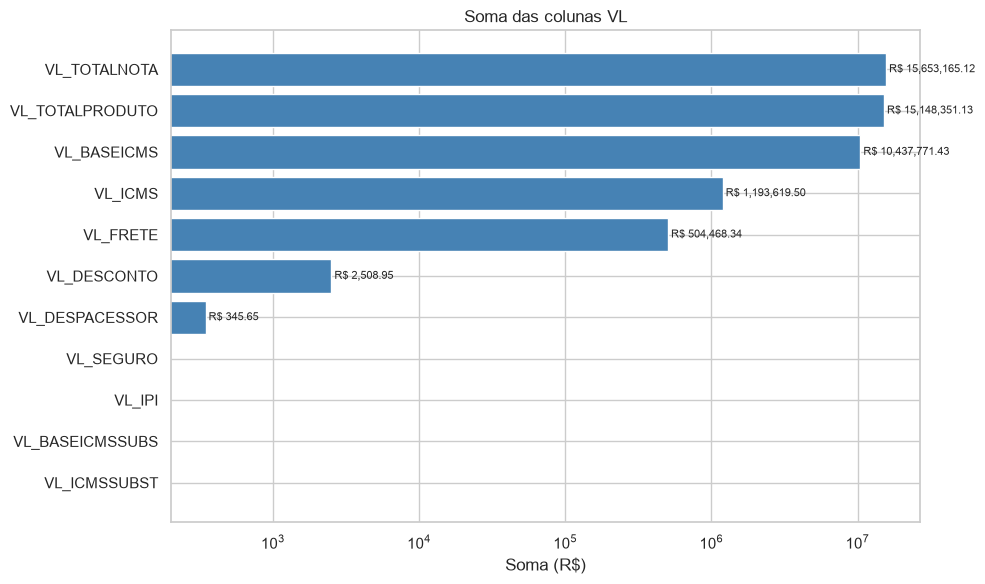

In [76]:
cols_vl = [col for col in df.columns if col.upper().startswith('VL')]
vl_sums = df[cols_vl].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(vl_sums.index[::-1], vl_sums.values[::-1], color='steelblue', edgecolor='white')
plt.title('Soma das colunas VL')
plt.xlabel('Soma (R$)')
plt.xscale('log')
for i, v in enumerate(vl_sums.values[::-1]):
    plt.text(v * 1.05, i, f'R$ {v:,.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### Avaliando candidato para análise do faturamento

In [77]:
df_fat_cand = df[
    (df['TP_SITUACAO'] == 'E') &
    (df['TP_OPERACAO'] == 'S')
].copy()

df_fat_cand.shape

df_fat_cand[['VL_TOTALNOTA', 'VL_TOTALPRODUTO', 'VL_FRETE', 'VL_DESCONTO']].sum()

df_fat_cand.groupby('CD_OPERACAO').agg(
    QTD_NOTAS=('NR_NF', 'size'),
    VL_TOTALNOTA=('VL_TOTALNOTA', 'sum'),
    VL_TOTALPRODUTO=('VL_TOTALPRODUTO', 'sum')
).sort_values('VL_TOTALNOTA', ascending=False)

df_fat_cand.groupby('TP_MODDCTOFISCAL').agg(
    QTD_NOTAS=('NR_NF', 'size'),
    VL_TOTALNOTA=('VL_TOTALNOTA', 'sum')
).sort_values('VL_TOTALNOTA', ascending=False)


In [78]:
df_fat_cand[['NR_NF', 'CD_SERIE']].duplicated().sum()

np.int64(0)

In [79]:
df_fat_cand[['NR_NF', 'CD_SERIE', 'TP_MODDCTOFISCAL']].duplicated().sum()


np.int64(0)

### Quantidade de notas por CD_OPERACAO no recorte de faturamento

No recorte candidato ao faturamento (`TP_SITUACAO = 'E'` e `TP_OPERACAO = 'S'`), o gráfico abaixo mostra como as notas se distribuem por código de operação, evidenciando o domínio do código 9998 (principal fluxo de saída comercial).

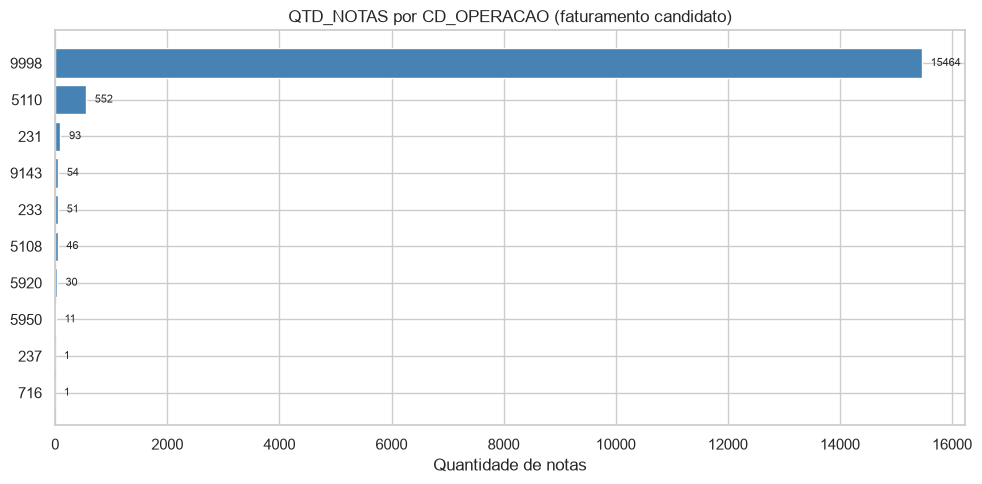

In [80]:
fat_op = (
    df_fat_cand.groupby('CD_OPERACAO')
      .agg(QTD_NOTAS=('NR_FATURA', 'size'))
      .sort_values('QTD_NOTAS', ascending=False)
)

plt.figure(figsize=(10, 5))
plt.barh(fat_op.index[::-1].astype(str), fat_op['QTD_NOTAS'].values[::-1],
         color='steelblue', edgecolor='white')
plt.title('QTD_NOTAS por CD_OPERACAO (faturamento candidato)')
plt.xlabel('Quantidade de notas')
for i, v in enumerate(fat_op['QTD_NOTAS'].values[::-1]):
    plt.text(v + max(fat_op['QTD_NOTAS'])*0.01, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

### VL_TOTALNOTA por CD_OPERACAO no recorte de faturamento

O valor total das notas no recorte de faturamento, agrupado por `CD_OPERACAO`, permitindo visualizar o peso financeiro de cada código operacional.

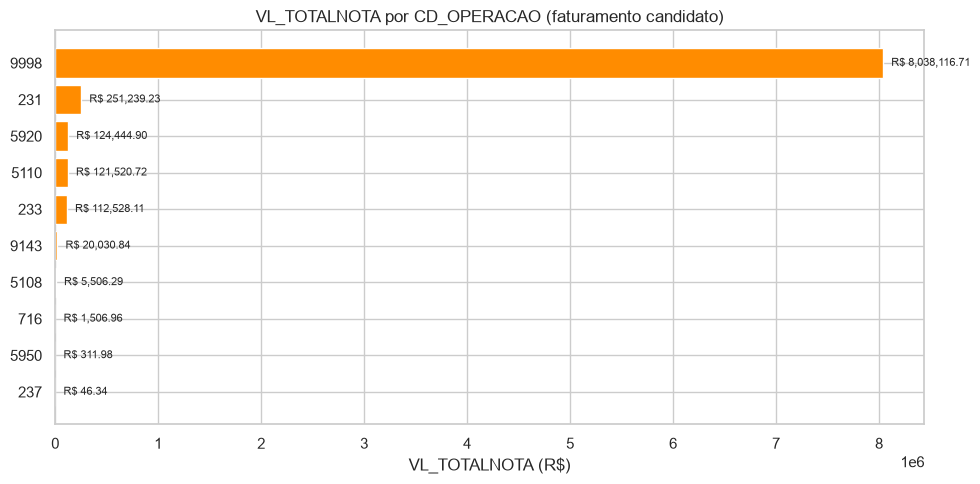

In [81]:
fat_vl = (
    df_fat_cand.groupby('CD_OPERACAO')
      .agg(VL_TOTALNOTA=('VL_TOTALNOTA', 'sum'))
      .sort_values('VL_TOTALNOTA', ascending=False)
)

plt.figure(figsize=(10, 5))
plt.barh(fat_vl.index[::-1].astype(str), fat_vl['VL_TOTALNOTA'].values[::-1],
         color='darkorange', edgecolor='white')
plt.title('VL_TOTALNOTA por CD_OPERACAO (faturamento candidato)')
plt.xlabel('VL_TOTALNOTA (R$)')
for i, v in enumerate(fat_vl['VL_TOTALNOTA'].values[::-1]):
    plt.text(v + max(fat_vl['VL_TOTALNOTA'])*0.01, i, f'R$ {v:,.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

# Conclusão

- A análise exploratória do cabeçalho de notas fiscais permitiu identificar os campos mais relevantes para a construção do relatório final e estabelecer uma base consistente para a etapa analítica principal.

- A coluna TP_SITUACAO se mostrou essencial para definir o universo válido de análise. Os registros em situação E representam o conjunto efetivamente aproveitável, enquanto os status C e X devem ficar fora da apuração principal, pois introduzem distorções na contagem documental e no faturamento.

- No aspecto operacional, TP_OPERACAO e CD_OPERACAO apresentaram alto poder explicativo. O comportamento observado indica uma separação clara entre entradas e saídas, o que contribui para distinguir o fluxo principal de faturamento dos demais movimentos da base, como devoluções e operações acessórias.

- A análise de unicidade documental mostrou que, embora existam duplicidades na base completa, esse problema desaparece no recorte candidato ao faturamento. No subconjunto com TP_SITUACAO = 'E' e TP_OPERACAO = 'S', não foram identificadas duplicidades nem pela combinação NR_NF + CD_SERIE, nem por NR_NF + CD_SERIE + TP_MODDCTOFISCAL. Isso torna esse recorte adequado para cálculo de quantidade de notas distintas e ticket médio por nota.

- Na dimensão temporal, DT_EMISSAO foi identificada como a melhor referência para o relatório.

- Do ponto de vista financeiro, VL_TOTALNOTA se mostrou a melhor candidata para representar o valor final da nota no cabeçalho. A composição dos valores indica que esse campo reflete principalmente VL_TOTALPRODUTO, VL_FRETE e VL_DESPACESSOR, enquanto descontos e outros componentes fiscais têm impacto reduzido ou irrelevante na apuração principal.

- A análise também permitiu definir, de forma provisória e consistente, o recorte candidato ao faturamento bruto: notas com TP_SITUACAO = 'E' e TP_OPERACAO = 'S'. Dentro desse conjunto, todas as notas pertencem ao TP_MODDCTOFISCAL = 55, reforçando a interpretação de que esse é o modelo documental central do faturamento de saída.

- Por fim, as colunas relacionadas à empresa não agregam segmentação neste conjunto analisado, pois apresentam um único valor ao longo da base. Assim, para este recorte específico, o relatório por empresa não exigirá particionamento adicional.

- Com isso, considera-se concluída a análise exploratória do cabeçalho do NF. Os resultados obtidos já são suficientes para avançar para a etapa principal do trabalho, com foco na definição final das regras de faturamento bruto e líquido e na integração com o nível de itens para análise de quantidades e produtos.

In [85]:
# Salvando arquivo final
df.to_csv(DATA_DIR / 'NF.csv', index=None)